In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import duckdb
import polars as pl
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)

from dafm import plots

In [3]:
alt_id_to_label = {
    # Lorenz96Bao2024EnSF
    'uha1a304': 'EnSF',  # sampling_time_step_count=10 rng_seed=462133975
    'xp29tge5': 'EnFF',  # sampling_time_step_count=10 rng_seed=462133975
    '9fastxa9': 'EnSF',  # sampling_time_step_count=20 rng_seed=462133975
    'dexfbenv': 'EnFF',  # sampling_time_step_count=20 rng_seed=462133975
    'nqbpry75': 'EnSF',  # sampling_time_step_count=50 rng_seed=462133975
    'q3lihp2g': 'EnFF',  # sampling_time_step_count=50 rng_seed=462133975
    '1xvp5lig': 'EnSF',  # sampling_time_step_count=10 rng_seed=2376999025
    'eriikp1u': 'EnFF',  # sampling_time_step_count=10 rng_seed=2376999025
    'pkwvt6gk': 'EnSF',  # sampling_time_step_count=20 rng_seed=2376999025
    '7igtkq4a': 'EnFF',  # sampling_time_step_count=20 rng_seed=2376999025
    'yq1eaqxr': 'EnSF',  # sampling_time_step_count=50 rng_seed=2376999025
    'h8l7xw8q': 'EnFF',  # sampling_time_step_count=50 rng_seed=2376999025

    # NavierStokesDim64
    # 'sfsy27vc': 'EnSF',  # sampling_time_step_count=20 rng_seed=97616566
    # 'f9908g7m': 'EnFF',  # sampling_time_step_count=20 rng_seed=97616566
    # '4f0eg86z': 'EnSF',  # sampling_time_step_count=50 rng_seed=97616566
    # '2w2rwf0c': 'EnFF',  # sampling_time_step_count=50 rng_seed=97616566
    # '7vww91h3': 'EnSF',  # sampling_time_step_count=20 rng_seed=462133975
    # 'qgmlcthg': 'EnFF',  # sampling_time_step_count=20 rng_seed=462133975
    # 'fk708dzr': 'EnSF',  # sampling_time_step_count=50 rng_seed=462133975
    # 'p1nvic4f': 'EnFF',  # sampling_time_step_count=50 rng_seed=462133975
    # 'pdcrol0s': 'EnSF',  # sampling_time_step_count=20 rng_seed=715319214
    # 'dhg0w990': 'EnFF',  # sampling_time_step_count=20 rng_seed=715319214
    # '0mgoi1k6': 'EnSF',  # sampling_time_step_count=50 rng_seed=715319214
    # 'daobe0dl': 'EnFF',  # sampling_time_step_count=50 rng_seed=715319214
    # 'w4tlx0pw': 'EnSF',  # sampling_time_step_count=20 rng_seed=979497033
    # '0d280i72': 'EnFF',  # sampling_time_step_count=20 rng_seed=979497033
    # 'qj161jfx': 'EnSF',  # sampling_time_step_count=50 rng_seed=979497033
    # '6oapd3dk': 'EnFF',  # sampling_time_step_count=50 rng_seed=979497033
    # 'cfbwxnup': 'EnFF',  # sampling_time_step_count=10 rng_seed=2376999025
    # 'c2f2fz7j': 'EnSF',  # sampling_time_step_count=20 rng_seed=2376999025
    # 'eijvq9xb': 'EnFF',  # sampling_time_step_count=20 rng_seed=2376999025
    # 'vpcuhvjp': 'EnSF',  # sampling_time_step_count=50 rng_seed=2376999025
    # 'fdyt2eb3': 'EnFF',  # sampling_time_step_count=50 rng_seed=2376999025
    
    # NavierStokesDim256
    # '4jkvp3sd': 'EnFF',  # sampling_time_step_count=20 rng_seed=97616566
    # 'y68jj7ko': 'EnSF',  # sampling_time_step_count=50 rng_seed=97616566
    # 'bmqxrqdh': 'EnFF',  # sampling_time_step_count=50 rng_seed=97616566
    # '9wgb8epw': 'EnFF',  # sampling_time_step_count=20 rng_seed=462133975
    # 'u38vggmy': 'EnFF',  # sampling_time_step_count=20 rng_seed=715319214
    # 'z19i455i': 'EnSF',  # sampling_time_step_count=50 rng_seed=715319214
    # '5561y8s3': 'EnFF',  # sampling_time_step_count=50 rng_seed=715319214
    # 'imfy6pzi': 'EnFF',  # sampling_time_step_count=20 rng_seed=979497033
    # 'in7i7zwn': 'EnFF',  # sampling_time_step_count=20 rng_seed=2376999025
    # 'uoc15dkh': 'EnSF',  # sampling_time_step_count=50 rng_seed=2376999025
    # 'jerb4qqb': 'EnFF',  # sampling_time_step_count=50 rng_seed=2376999025

    # KuramotoSivashinsky
    # '3k2gte7o': 'EnSF',  # sampling_time_step_count=10 rng_seed=97616566
    # 'r0x03bpn': 'EnFF',  # sampling_time_step_count=10 rng_seed=97616566
    # 'dpay746j': 'EnSF',  # sampling_time_step_count=20 rng_seed=97616566
    # 'r6j7mz7t': 'EnFF',  # sampling_time_step_count=20 rng_seed=97616566
    # 'rsykevhy': 'EnSF',  # sampling_time_step_count=50 rng_seed=97616566
    # '1s790g5z': 'EnFF',  # sampling_time_step_count=50 rng_seed=97616566
    # 'la8cajc1': 'EnSF',  # sampling_time_step_count=10 rng_seed=462133975
    # 'g671jhti': 'EnFF',  # sampling_time_step_count=10 rng_seed=462133975
    # 'as4tbkeo': 'EnSF',  # sampling_time_step_count=20 rng_seed=462133975
    # 'k8usyldj': 'EnFF',  # sampling_time_step_count=20 rng_seed=462133975
    # 'h3rgu5rf': 'EnSF',  # sampling_time_step_count=50 rng_seed=462133975
    # 'ktvdxqq6': 'EnFF',  # sampling_time_step_count=50 rng_seed=462133975
    # 'mhvfqefv': 'EnSF',  # sampling_time_step_count=10 rng_seed=715319214
    # 'uevs40qo': 'EnFF',  # sampling_time_step_count=10 rng_seed=715319214
    # 'dsmyu7gu': 'EnSF',  # sampling_time_step_count=20 rng_seed=715319214
    # '71qimf5i': 'EnFF',  # sampling_time_step_count=20 rng_seed=715319214
    # 'b1x9phjs': 'EnSF',  # sampling_time_step_count=50 rng_seed=715319214
    # '4bcjvj74': 'EnFF',  # sampling_time_step_count=50 rng_seed=715319214
    # '6pd7d6zp': 'EnSF',  # sampling_time_step_count=10 rng_seed=979497033
    # 'g9d5c2af': 'EnFF',  # sampling_time_step_count=10 rng_seed=979497033
    # 'lzm4recz': 'EnSF',  # sampling_time_step_count=20 rng_seed=979497033
    # 'myod1mnu': 'EnFF',  # sampling_time_step_count=20 rng_seed=979497033
    # 'e1bw0o3j': 'EnSF',  # sampling_time_step_count=50 rng_seed=979497033
    # 'erilhzbx': 'EnFF',  # sampling_time_step_count=50 rng_seed=979497033
    # 'dwrinhfi': 'EnSF',  # sampling_time_step_count=10 rng_seed=2376999025
    # 'ic8igmlg': 'EnFF',  # sampling_time_step_count=10 rng_seed=2376999025
    # 'glis0of9': 'EnSF',  # sampling_time_step_count=20 rng_seed=2376999025
    # '1h275uvu': 'EnFF',  # sampling_time_step_count=20 rng_seed=2376999025
    # 'wpp5ymyl': 'EnSF',  # sampling_time_step_count=50 rng_seed=2376999025
    # 'fje0w213': 'EnFF',  # sampling_time_step_count=50 rng_seed=2376999025
}
alt_ids = pl.DataFrame(list(alt_id_to_label.items()), schema=['alt_id', 'label'], orient='row')
alt_ids

alt_id,label
str,str
"""uha1a304""","""EnSF"""
"""xp29tge5""","""EnFF"""
"""9fastxa9""","""EnSF"""
"""dexfbenv""","""EnFF"""
"""nqbpry75""","""EnSF"""
…,…
"""eriikp1u""","""EnFF"""
"""pkwvt6gk""","""EnSF"""
"""7igtkq4a""","""EnFF"""


In [4]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

In [5]:
duckdb.sql("""
set variable time_step_times_filepaths = (
    -- select list(format('/mnta/taosData/dafm/runs_sci_2025-05/{}/time_step_times.csv', alt_id)) from alt_ids
    select list(format('~/out/dafm/runs/{}/time_step_times.csv', alt_id)) from alt_ids
);
""")

In [6]:
time_step_times = duckdb.sql("""
select
    csvs.alt_id,
    label,
    rng_seed,
    sampling_time_step_count as "Sampling timesteps",
    step,
    observe_every_n_time_steps,
    time_s as "Time (s)" from (
    select
        split(filename, '/')[-2] as alt_id,
        step,
        time_s
    from read_csv(getvariable(time_step_times_filepaths), filename=true)
) as csvs
join alt_ids on alt_ids.alt_id = csvs.alt_id
join Conf on Conf.alt_id = alt_ids.alt_id
join Dataset on Conf.Dataset = Dataset.id
join (
    select id, sampling_time_step_count
    from ScoreMatchingMarginal
    union
    select id, sampling_time_step_count
    from FlowMatchingMarginal
) as models on Conf.Model = models.id
;
""").pl()
time_step_times

alt_id,label,rng_seed,Sampling timesteps,step,observe_every_n_time_steps,Time (s)
str,str,i64,i64,i64,i64,f64
"""uha1a304""","""EnSF""",462133975,10,1,10,24.011191
"""uha1a304""","""EnSF""",462133975,10,2,10,12.01563
"""uha1a304""","""EnSF""",462133975,10,3,10,22.633458
"""uha1a304""","""EnSF""",462133975,10,4,10,22.368926
"""uha1a304""","""EnSF""",462133975,10,5,10,22.0038
…,…,…,…,…,…,…
"""h8l7xw8q""","""EnFF""",2376999025,50,796,10,20.014655
"""h8l7xw8q""","""EnFF""",2376999025,50,797,10,19.712717
"""h8l7xw8q""","""EnFF""",2376999025,50,798,10,20.765451


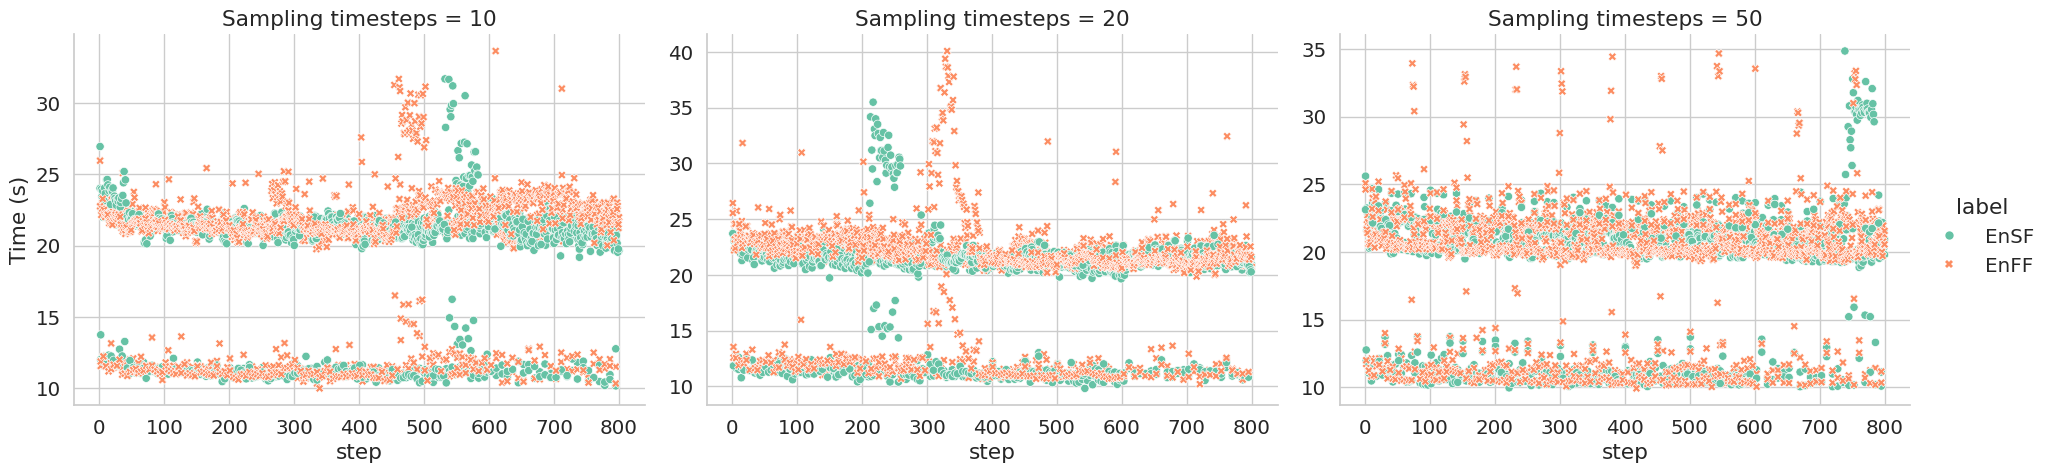

In [7]:
(
    sns.relplot(
        # kind='line',
        data=time_step_times,
        x='step',
        y='Time (s)',
        hue='label',
        style='label',
        col='Sampling timesteps',
        # markers=True,
        # markersize=10,
        aspect=1.3,
        facet_kws=dict(
            sharey=False,
        )
    )
)

shape: (12, 5)
┌──────────┬───────┬────────────┬────────────────────┬───────────┐
│ alt_id   ┆ label ┆ rng_seed   ┆ Sampling timesteps ┆ Time (s)  │
│ ---      ┆ ---   ┆ ---        ┆ ---                ┆ ---       │
│ str      ┆ str   ┆ i64        ┆ i64                ┆ f64       │
╞══════════╪═══════╪════════════╪════════════════════╪═══════════╡
│ eriikp1u ┆ EnFF  ┆ 2376999025 ┆ 10                 ┆ 20.337642 │
│ xp29tge5 ┆ EnFF  ┆ 462133975  ┆ 10                 ┆ 19.938686 │
│ 7igtkq4a ┆ EnFF  ┆ 2376999025 ┆ 20                 ┆ 21.152904 │
│ dexfbenv ┆ EnFF  ┆ 462133975  ┆ 20                 ┆ 20.859131 │
│ h8l7xw8q ┆ EnFF  ┆ 2376999025 ┆ 50                 ┆ 20.27208  │
│ …        ┆ …     ┆ …          ┆ …                  ┆ …         │
│ uha1a304 ┆ EnSF  ┆ 462133975  ┆ 10                 ┆ 19.397836 │
│ pkwvt6gk ┆ EnSF  ┆ 2376999025 ┆ 20                 ┆ 20.473157 │
│ 9fastxa9 ┆ EnSF  ┆ 462133975  ┆ 20                 ┆ 19.859235 │
│ yq1eaqxr ┆ EnSF  ┆ 2376999025 ┆ 50           

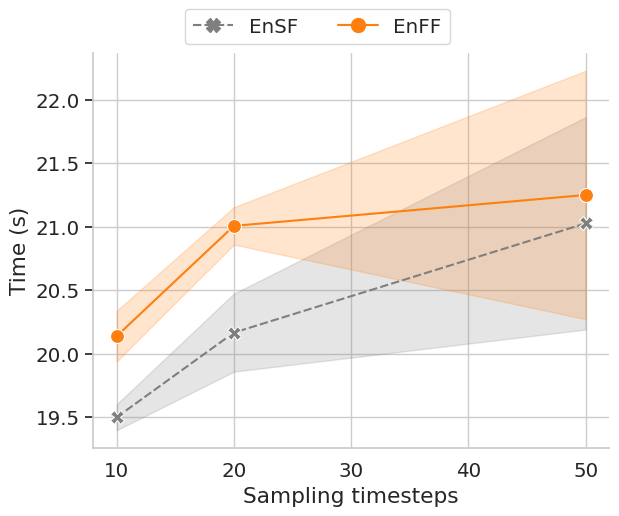

In [8]:
data = (
    time_step_times
    .filter(
        (pl.col('step') - 1) % pl.col('observe_every_n_time_steps') == 0
    )
    .group_by('alt_id', 'label', 'rng_seed', 'Sampling timesteps')
    .agg(pl.col('Time (s)').mean())
    .sort('label', 'Sampling timesteps')
)
print(data)
plot_times = (
    sns.relplot(
        kind='line',
        data=data,
        x='Sampling timesteps',
        y='Time (s)',
        hue='label',
        hue_order=['EnSF', 'EnFF'],
        style='label',
        palette={
            'EnSF': 'tab:gray',
            'EnFF': 'tab:orange',
        },
        markers=True,
        markersize=10,
        aspect=1.3,
    )
    .set(
        # xscale='log',
        # yscale='log',
    )
)
ax_twin = plot_times.axes[0][0].twinx()
ax_twin.set_axis_off()
sns.move_legend(
    plot_times,
    loc='upper center',
    ncol=min(len(alt_ids), 2) + 1,
    title='',
    bbox_to_anchor=(.455, 1.06),
    frameon=True,
    fancybox=True,
)

In [13]:
table = (
    data
    .group_by('label', 'Sampling timesteps')
    .agg(
        pl.col('Time (s)').mean().alias('Time mean (s)'),
        pl.col('Time (s)').std(ddof=0).alias('Time std. (s)'),
    )
    .select(
        # pl.format('{} {}', pl.col('label'), pl.col('Sampling timesteps')).alias('Model'),
        pl.col('label').alias('Model'),
        pl.col('Sampling timesteps').alias('$T$'),
        # (pl.col('label') + ' (' + pl.col('Sampling timesteps').cast(str) + ')').alias('Model'),
        pl.format(
            r'${}_{{\pm {}}}$',
            pl.col('Time mean (s)').map_elements(lambda x: f'{x:.3f}', return_dtype=str),
            pl.col('Time std. (s)').map_elements(lambda x: f'{x:.3f}', return_dtype=str),
        ).alias('Time (s)'),
    )
    .sort('Model')
)
table

Model,$T$,Time (s)
str,i64,str
"""EnFF""",50,"""$21.249_{{\pm 0.977}}$"""
"""EnFF""",10,"""$20.138_{{\pm 0.199}}$"""
"""EnFF""",20,"""$21.006_{{\pm 0.147}}$"""
"""EnSF""",10,"""$19.500_{{\pm 0.102}}$"""
"""EnSF""",20,"""$20.166_{{\pm 0.307}}$"""
"""EnSF""",50,"""$21.026_{{\pm 0.836}}$"""


In [14]:
print(table.to_pandas().to_latex(index=False))

\begin{tabular}{lrl}
\toprule
Model & $T$ & Time (s) \\
\midrule
EnFF & 50 & $21.249_{{\pm 0.977}}$ \\
EnFF & 10 & $20.138_{{\pm 0.199}}$ \\
EnFF & 20 & $21.006_{{\pm 0.147}}$ \\
EnSF & 10 & $19.500_{{\pm 0.102}}$ \\
EnSF & 20 & $20.166_{{\pm 0.307}}$ \\
EnSF & 50 & $21.026_{{\pm 0.836}}$ \\
\bottomrule
\end{tabular}



In [11]:
plots.save_all_subfigures(plot_times, 'ExecutionTimeSum')